In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

In [12]:
train_path = "../mnist_png/training"
test_path = "../mnist_png/testing"

In [14]:
print("Training Exists :", os.path.exists(train_path))
print("Testing Exists  :", os.path.exists(test_path))

Training Exists : True
Testing Exists  : True


In [15]:
print(os.listdir(train_path))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [16]:
for digit in sorted(os.listdir(train_path)):
    folder = os.path.join(train_path, digit)
    print(f"Digit {digit} : {len(os.listdir(folder))} images")

Digit 0 : 5923 images
Digit 1 : 6742 images
Digit 2 : 5958 images
Digit 3 : 6131 images
Digit 4 : 5842 images
Digit 5 : 5421 images
Digit 6 : 5918 images
Digit 7 : 6265 images
Digit 8 : 5851 images
Digit 9 : 5949 images


In [19]:
def load_images(folder_path):

    images = []
    labels = []

    for label in range(10):

        digit_folder = os.path.join(folder_path, str(label))

        for filename in os.listdir(digit_folder):

            image_path = os.path.join(digit_folder, filename)

            image = Image.open(image_path).convert("L")

            image = np.array(image)

            images.append(image)

            labels.append(label)

    return np.array(images), np.array(labels)

In [20]:
x_train, y_train = load_images(train_path)

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)


In [21]:
x_test, y_test = load_images(test_path)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


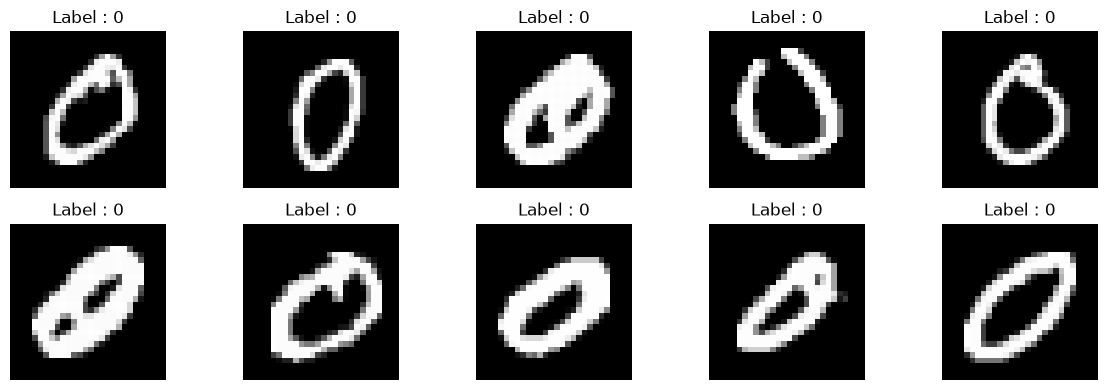

In [22]:
plt.figure(figsize=(12,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i], cmap='gray')

    plt.title(f"Label : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [23]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum Pixel :", x_train.min())
print("Maximum Pixel :", x_train.max())

Minimum Pixel : 0.0
Maximum Pixel : 1.0


In [24]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [25]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

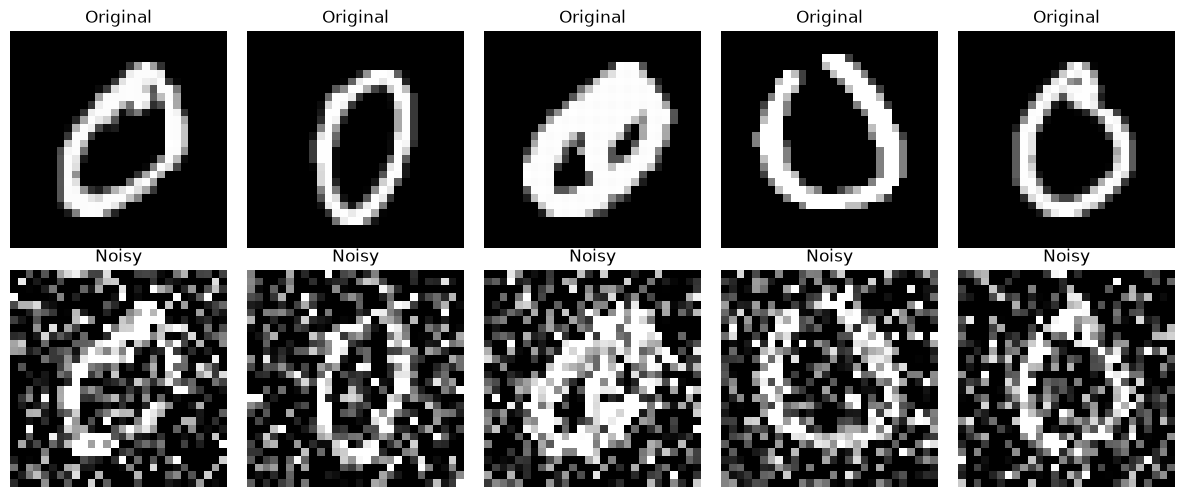

In [26]:
plt.figure(figsize=(12,5))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
## 6. Build Denoising Autoencoder
# The autoencoder consists of two parts:
# 1. Encoder - Compresses the noisy image into a smaller representation.
# 2. Decoder - Reconstructs the clean image from the compressed representation.

In [29]:
input_img = Input(shape=(28, 28, 1))

In [30]:
# Encoder

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)

x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)

encoded = MaxPooling2D((2,2), padding='same')(x)

In [31]:
# Decoder

x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)

In [32]:
autoencoder = Model(input_img, decoded)

In [33]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [36]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.1741 - val_loss: 0.1211
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1175 - val_loss: 0.1125
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1115 - val_loss: 0.1083
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1080 - val_loss: 0.1057
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1056 - val_loss: 0.1036
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1041 - val_loss: 0.1038
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1030 - val_loss: 0.1015
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1022 - val_loss: 0.1007
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1016 - val_loss: 0.1004
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1010 - val_loss: 0.0999
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1006 - val_loss: 0.0993
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 

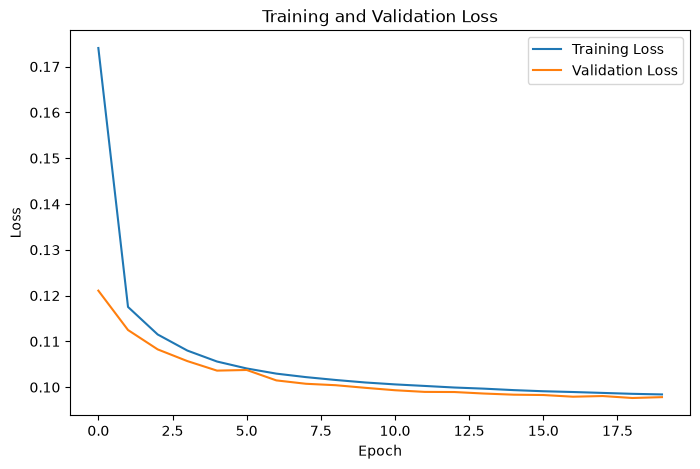

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [38]:
# Generate denoised images

decoded_images = autoencoder.predict(x_test_noisy)

print("Shape of Denoised Images:", decoded_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Shape of Denoised Images: (10000, 28, 28, 1)


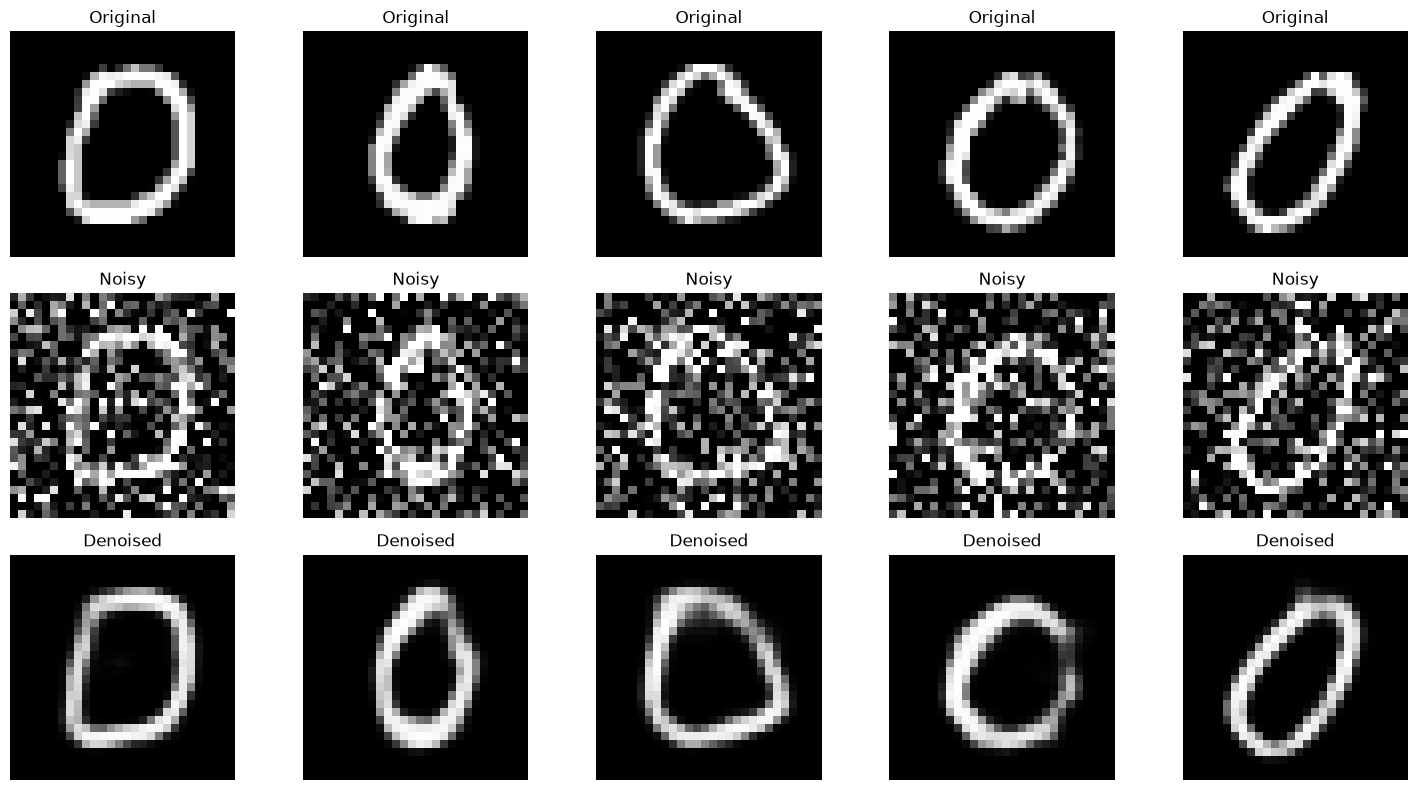

In [39]:
plt.figure(figsize=(15, 8))

n = 5

for i in range(n):

    # Original Images
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Images
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.flatten(),
    decoded_images.flatten()
)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.011568596586585045


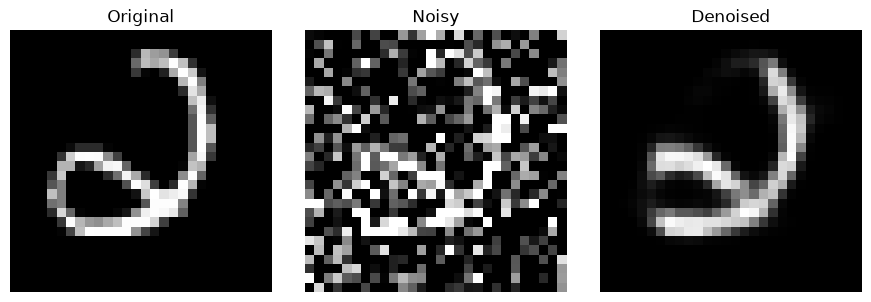

In [41]:
import random

index = random.randint(0, len(x_test)-1)

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(x_test_noisy[index].reshape(28,28), cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(decoded_images[index].reshape(28,28), cmap='gray')
plt.title("Denoised")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
## Observations

- The denoising autoencoder successfully learned to reconstruct clean images from noisy inputs.
- Gaussian noise significantly degraded the visual quality of the handwritten digits, but the model was able to remove most of the noise.
- The reconstructed images preserved the overall digit structure, although a few digits appeared slightly blurred.
- Training and validation loss decreased steadily over the epochs, indicating that the model learned meaningful image features.
- Simple digits such as "1" and "7" were reconstructed more accurately than more complex digits such as "8" and "9".

In [ ]:
## Challenges

- Loading thousands of PNG images required preprocessing before training.
- Choosing an appropriate noise factor involved experimentation.
- Training on the CPU increased execution time compared to GPU-based training.
- Some reconstructed images lost fine details due to compression in the latent representation.

In [ ]:
## Future Improvements

- Increase the depth of the encoder and decoder.
- Experiment with different noise levels.
- Apply Batch Normalization to improve convergence.
- Compare Binary Crossentropy with Mean Squared Error as the loss function.
- Evaluate the model using additional image quality metrics such as SSIM and PSNR.

In [ ]:
## Conclusion

A Convolutional Denoising Autoencoder was successfully implemented to remove Gaussian noise from handwritten digit images. The model learned compact feature representations through the encoder and reconstructed clean images using the decoder. The experimental results demonstrate that the trained model effectively reduces noise while preserving the essential digit structures. This approach highlights the usefulness of autoencoders for image restoration tasks.